# 환경설정/데이터 불러오기

In [1]:
# 3.10 버전 기준
"pip install pandas numpy matplotlib seaborn scikit-learn lightgbm catboost   # 3.14.0 버전에서는 주석 처리 필요"

'pip install pandas numpy matplotlib seaborn scikit-learn lightgbm catboost   # 3.14.0 버전에서는 주석 처리 필요'

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import re
import requests

import warnings
warnings.filterwarnings('ignore')

In [3]:
pip install lgb

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement lgb (from versions: none)
ERROR: No matching distribution found for lgb


In [4]:
# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [6]:
# log 스케일링, 가중치 설정, RankGauss 정규분포 적용 안 한 데이터프레임 import
df = pd.read_csv(r'C:\Users\junsu\Documents\codeit_study\처음청약\모델링 학습용 데이터(수정 전).csv', encoding='utf-8', na_values=[])
df.head(3)

,단지명,주택형,모집공고일,주택관리번호,생애최초 배정세대수,신혼부부 배정세대수,다자녀 배정세대수,노부모 배정세대수,해당지역 생애최초 접수건수,해당지역 신혼부부 접수건수,...,한강권,y,정책버전,경과개월,월_sin,월_cos,특공_배정총합,특공_접수총합,주택형_알파벳,브랜드
0,반포 래미안 트리니원,059.9400A,2025-10-31,2025000527,20,50,22,7,5366,4199,...,1,5.505982,3,68,-0.866025,0.5,99,13578,A,래미안
1,반포 래미안 트리니원,059.9800B,2025-10-31,2025000527,12,28,14,4,1642,1403,...,1,5.296265,3,68,-0.866025,0.5,58,4620,B,래미안
2,반포 래미안 트리니원,059.8500C,2025-10-31,2025000527,2,8,0,1,330,269,...,1,5.032462,3,68,-0.866025,0.5,11,739,C,래미안


# 분석 결과 비교

피처 엔지니어링 기법(로그·가우시안·스케일링·가중치 적용 유무)이 서울 아파트 일반공급 경쟁률 예측의 정확도·안정성·설명력에 미치는 영향을 정량적으로 검증해보기

추가 피처 없이 동일 변수셋에서 변환 전·후를 비교 분석하여 결과 도출해보기

## 특공 컬럼 관련 추가 정리

In [7]:
assign_col = "특공_배정총합"  
apply_col = "특공_접수총합"    

# 케이스 분류
case_A = (df[assign_col] == 0) & (df[apply_col] == 0)
case_B = (df[assign_col] > 0) & (df[apply_col] == 0)
case_C = (df[assign_col] > 0) & (df[apply_col] > 0)

# 개수
cnt_A = case_A.sum()
cnt_B = case_B.sum()
cnt_C = case_C.sum()
total = len(df)

# 비율 출력
print(f"특공 제도 없음 (배정 0 & 접수 0): {cnt_A}건 ({cnt_A/total*100:.2f}%)")
print(f"특공 지원자 없음 (배정 > 0 & 접수 0): {cnt_B}건 ({cnt_B/total*100:.2f}%)")
print(f"특공 정상 수요 (배정 > 0 & 접수 > 0): {cnt_C}건 ({cnt_C/total*100:.2f}%)")
print(f"총 건수: {total}")

특공 제도 없음 (배정 0 & 접수 0): 734건 (66.43%)
특공 지원자 없음 (배정 > 0 & 접수 0): 12건 (1.09%)
특공 정상 수요 (배정 > 0 & 접수 > 0): 359건 (32.49%)
총 건수: 1105


| 케이스 | 의미           | 설명              |
| --- | ------------ | ----------------------------- |
| A   | 제도 없음        | 수요 부재가 아니라 정의 자체 불가      |
| B   | 제도 있는데 관심 없음 | 0은 실제 수요 없음 의미 → 중요 학습 신호 |
| C   | 수요 존재        | 수요와 경쟁률 상관성 학습 가능             |

In [8]:
# 특공 비율 구분하는 추가 피처 생성
df['특공존재여부'] = (df[assign_col] > 0).astype(int)                  # 특공 제도 존재 여부
df['특공무지원']   = ((df[assign_col] > 0) & (df[apply_col] == 0)).astype(int)  # B 케이스 표시

# 특공수요비율 재정의
df['특공수요비율'] = (df[apply_col] / df[assign_col]).round(2)
df.loc[case_A, '특공수요비율'] = np.nan   # 제도 미존재 → 비율 정의 불가이므로 NaN
# case_B는 의미 있는 0 그대로 유지
# case_C는 기존 비율 유지 

In [9]:
# 기존 컬럼 제거
df.drop(columns=['특별공급수요비율'], inplace=True) 

In [10]:
"""df.to_excel('모델링 학습용 데이터(최신).xlsx', index=False, engine='openpyxl')"""

"df.to_excel('모델링 학습용 데이터(최신).xlsx', index=False, engine='openpyxl')"

## 실험 대상 컬럼 최종 선정

| 컬럼명 | 작업 내용 | 
| :--- | :--- |
| 시/군/구 | weight |
| 일반공급 공급세대수 | gauss 정규화 |
| 일반공급 접수건수 | 로그 스케일링 | 

## 기초 EDA

In [11]:
df.describe()

,주택관리번호,생애최초 배정세대수,신혼부부 배정세대수,다자녀 배정세대수,노부모 배정세대수,해당지역 생애최초 접수건수,해당지역 신혼부부 접수건수,해당지역 다자녀 접수건수,해당지역 노부모 접수건수,기타지역 생애최초 접수건수,...,y,정책버전,경과개월,월_sin,월_cos,특공_배정총합,특공_접수총합,특공존재여부,특공무지원,특공수요비율
count,1.105000e+03,1105.000000,1105.000000,1105.000000,1105.000000,1105.000000,1105.000000,1105.000000,1105.000000,1105.000000,...,1105.000000,1105.000000,1105.000000,1105.000000,1105.000000,1105.000000,1105.000000,1105.000000,1105.00000,371.000000
mean,2.022254e+09,1.248869,2.617195,1.327602,0.403620,129.638914,99.304977,19.834389,5.008145,32.869683,...,3.659425,1.656109,32.442534,-0.211219,-0.099658,5.597285,321.609955,0.335747,0.01086,65.182291
std,1.684981e+06,4.476039,8.112606,3.779163,1.181065,610.196984,382.702357,121.384878,22.016153,163.570485,...,1.709931,0.488381,20.533611,0.658317,0.716192,16.443188,1279.566769,0.472465,0.10369,122.897239
min,2.020000e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,2.021000e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.302585,1.000000,12.000000,-0.866025,-0.866025,0.000000,0.000000,0.000000,0.00000,6.000000
50%,2.022001e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.713572,2.000000,33.000000,-0.500000,-0.500000,0.000000,0.000000,0.000000,0.00000,19.620000
75%,2.024000e+09,0.000000,2.000000,1.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,...,4.955827,2.000000,52.000000,0.500000,0.500000,4.000000,38.000000,1.000000,0.00000,73.165000
max,2.025001e+09,62.000000,110.000000,40.000000,12.000000,10163.000000,4427.000000,2025.000000,355.000000,2582.000000,...,10.465301,3.000000,68.000000,1.000000,1.000000,191.000000,15025.000000,1.000000,1.00000,1149.780000


In [12]:
df.duplicated().sum()

0

In [13]:
import lightgbm as lgb

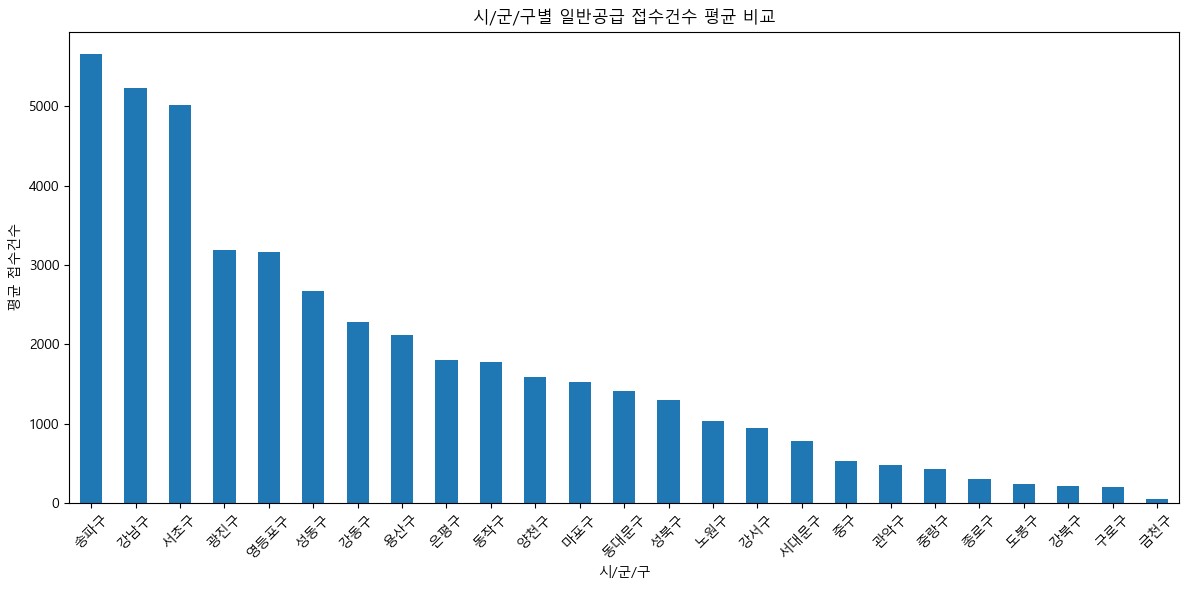

In [14]:
# 시군구별 평균 접수건수 비교
df_group = df.groupby("시/군/구")["일반공급 접수건수"].mean().sort_values(ascending=False).astype(int)

plt.figure(figsize=(12,6))
df_group.plot(kind='bar')
plt.title("시/군/구별 일반공급 접수건수 평균 비교")
plt.ylabel("평균 접수건수")
plt.xlabel("시/군/구")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

송파구, 강남구, 서초구가 타 지역 대비 월등히 높은 접수량 보임.

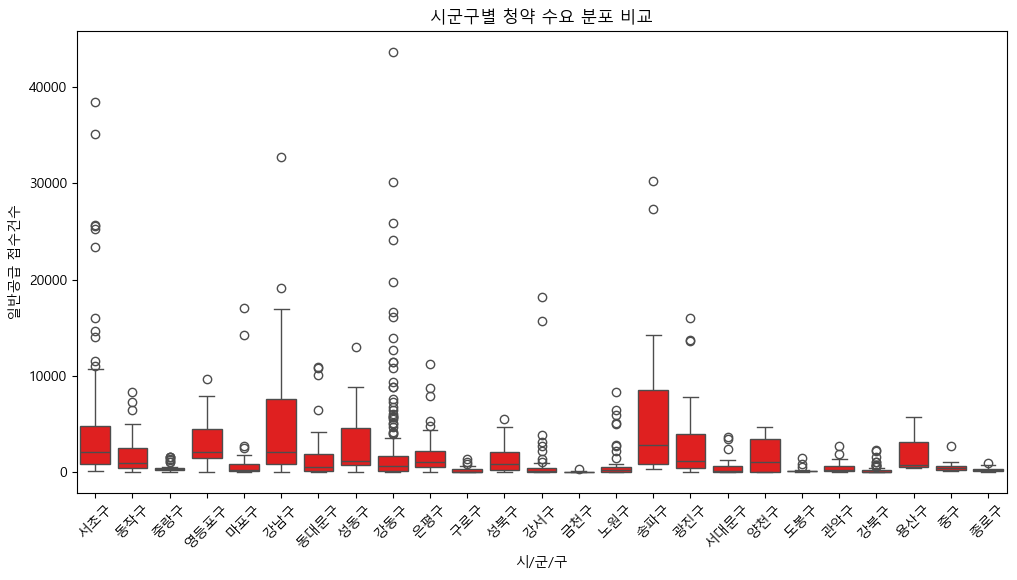

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="시/군/구", y="일반공급 접수건수", color='red')
plt.xticks(rotation=45)
plt.title("시군구별 청약 수요 분포 비교")
plt.show()


### 자치구별 일반공급 경쟁률 분포(Boxplot)

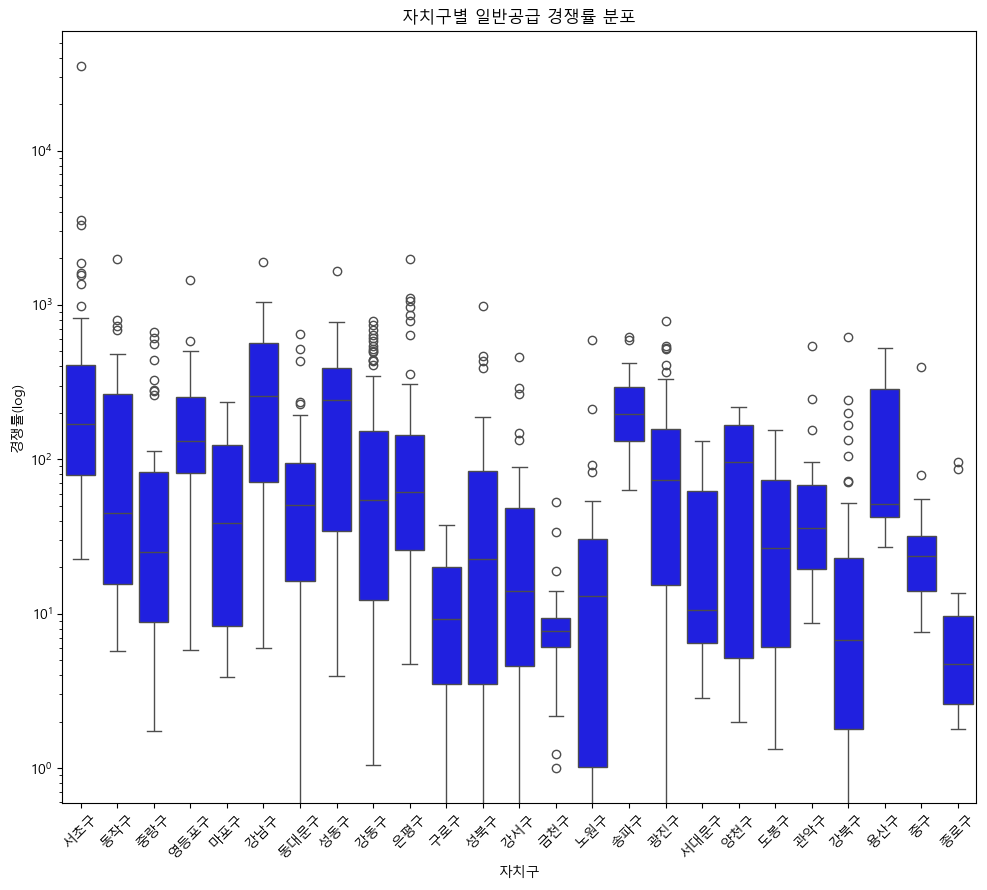

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 9))
sns.boxplot(
    data=df,
    x="시/군/구",
    y="일반공급 경쟁률",
    color='blue'
)

plt.xticks(rotation=45)
plt.yscale("log")   # long-tail 보정
plt.title("자치구별 일반공급 경쟁률 분포")
plt.ylabel("경쟁률(log)")
plt.xlabel("자치구")
plt.tight_layout()
plt.show()

In [17]:
df.duplicated().sum()

0

### 특공수요 비율 

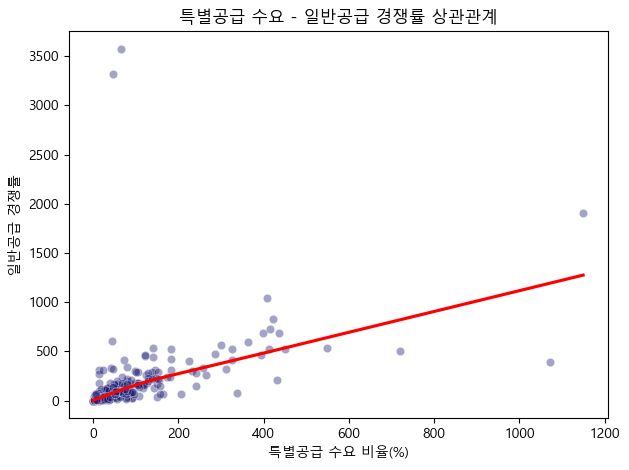

In [18]:
sns.scatterplot(
    x='특공수요비율',
    y='일반공급 경쟁률',
    data=df,
    alpha=0.4,
    color='midnightblue',
    edgecolor='white'
)

sns.regplot(
    x='특공수요비율',
    y='일반공급 경쟁률',
    data=df,
    scatter=False,
    lowess=True,
    color='red'
)

plt.xlabel('특별공급 수요 비율(%)')
plt.ylabel('일반공급 경쟁률') 
plt.title('특별공급 수요 - 일반공급 경쟁률 상관관계')

plt.tight_layout()
plt.show()

### 경쟁률 분포 히스토그램

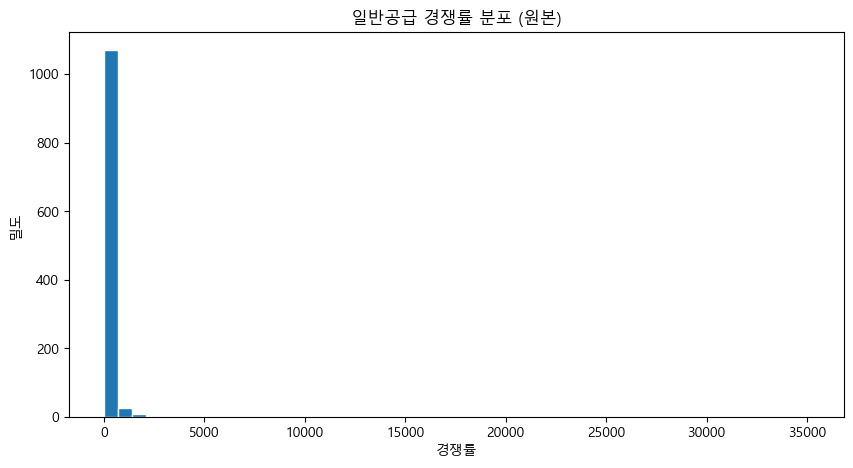

In [19]:
# 원본
plt.figure(figsize=(10,5))
plt.hist(df["일반공급 경쟁률"], bins=50, edgecolor='white')
plt.title("일반공급 경쟁률 분포 (원본)")
plt.xlabel("경쟁률")
plt.ylabel("밀도")
plt.show()

In [53]:
import pandas as pd
import numpy as np

# 1. 경쟁률 기준 내림차순 정렬 (컬럼명이 '일반공급 경쟁률'이 아닐 경우 실제 이름으로 수정하세요)
target_col = '일반공급 경쟁률'
df_sorted = df.sort_values(by=target_col, ascending=False).reset_index(drop=True)

# 2. 전체 경쟁률 합계 및 누적 비중 계산
total_sum = df_sorted[target_col].sum()
df_sorted['누적_비중'] = (df_sorted[target_col].cumsum() / total_sum) * 100

# 3. 주요 구간별 왜곡도 출력
print(f"--- {target_col} 왜곡도 분석 결과 ---")
percentiles = [1, 5, 10, 20]
for p in percentiles:
    idx = int(len(df_sorted) * (p / 100))
    # 인덱스가 범위를 벗어나지 않도록 조정
    actual_idx = min(idx, len(df_sorted) - 1)
    ratio = df_sorted.loc[actual_idx, '누적_비중']
    print(f"상위 {p}% 단지(약 {actual_idx+1}개)가 전체 경쟁률 총합의 {ratio:.1f}%를 차지함")

# 4. 평균 vs 중앙값 비교 (왜곡의 척도)
mean_val = df_sorted[target_col].mean()
median_val = df_sorted[target_col].median()
skewness = df_sorted[target_col].skew()

print(f"\n평균값: {mean_val:.2f} | 중앙값: {median_val:.2f}")
print(f"평균이 중앙값의 {mean_val/median_val:.1f}배 수준 (왜곡도가 높을수록 배수가 커짐)")
print(f"왜곡도(Skewness) 지수: {skewness:.2f} (3 이상이면 매우 높음)")

--- 일반공급 경쟁률 왜곡도 분석 결과 ---
상위 1% 단지(약 12개)가 전체 경쟁률 총합의 31.8%를 차지함
상위 5% 단지(약 56개)가 전체 경쟁률 총합의 50.0%를 차지함
상위 10% 단지(약 111개)가 전체 경쟁률 총합의 63.9%를 차지함
상위 20% 단지(약 222개)가 전체 경쟁률 총합의 78.8%를 차지함

평균값: 163.31 | 중앙값: 40.00
평균이 중앙값의 4.1배 수준 (왜곡도가 높을수록 배수가 커짐)
왜곡도(Skewness) 지수: 30.34 (3 이상이면 매우 높음)


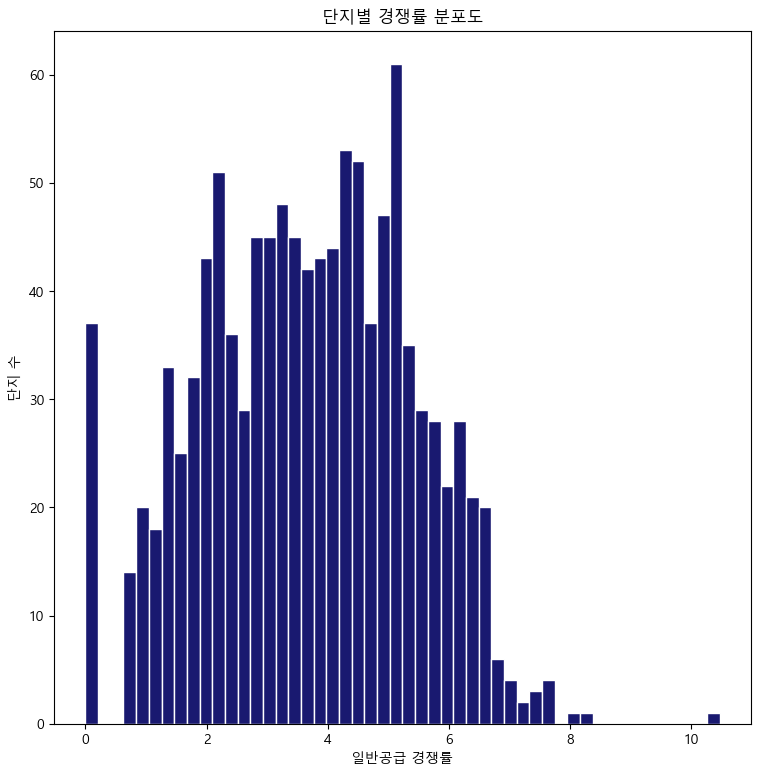

In [20]:
# 로그 스케일링 적용
plt.figure(figsize=(9,9))
plt.hist(np.log(df['일반공급 경쟁률']+1), bins=50, color='midnightblue', edgecolor='white')
plt.title("단지별 경쟁률 분포도")
plt.xlabel("일반공급 경쟁률")
plt.ylabel("단지 수")
plt.show()

### 공급세대수 vs 경쟁률

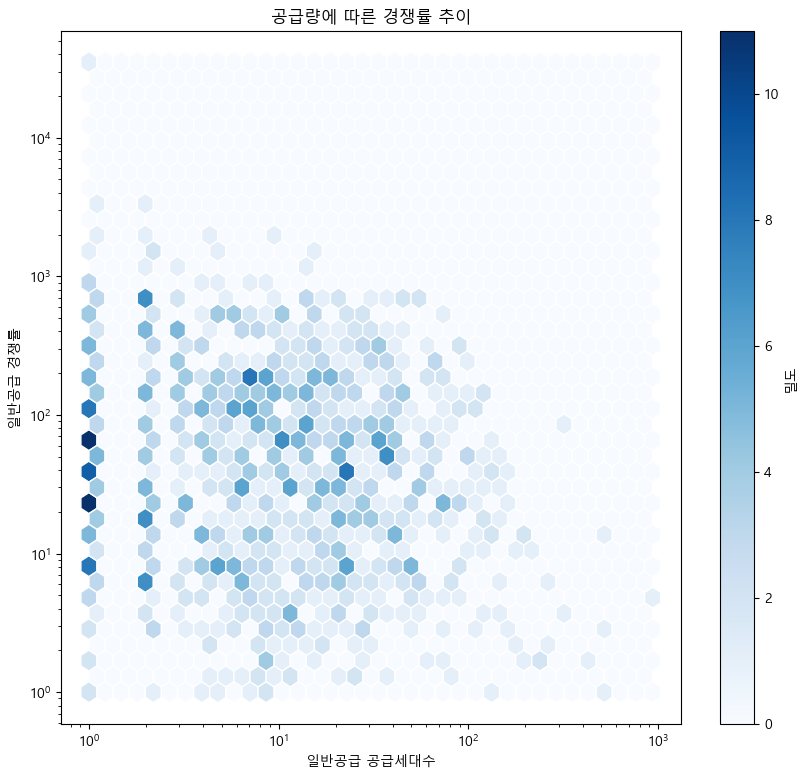

In [21]:
df_filtered = df[(df["일반공급 공급세대수"] > 0) & (df["일반공급 경쟁률"] > 0)]

plt.figure(figsize=(10,9))
plt.hexbin(
    df_filtered["일반공급 공급세대수"],
    df_filtered["일반공급 경쟁률"],
    gridsize=35,
    cmap="Blues",
    xscale="log",
    yscale="log",
    edgecolor='white'
)

plt.colorbar(label="밀도")
plt.xlabel("일반공급 공급세대수")
plt.ylabel("일반공급 경쟁률")
plt.title("공급량에 따른 경쟁률 추이")
plt.show()

## 8개 실험 자동화 코드

In [22]:
import numpy as np
from sklearn.preprocessing import QuantileTransformer

# 공급세대수 RankGauss 정규화
qt = QuantileTransformer(output_distribution="normal", random_state=42)
df['공급세대수_gauss'] = qt.fit_transform(df[['일반공급 공급세대수']])

# 시군구 Weight 생성
gu_mean = df.groupby('시/군/구')['일반공급 접수건수'].mean()
df['시군구_weight'] = df['시/군/구'].map(gu_mean)
df['시군구_weight'] = df['시군구_weight'].fillna(df['시군구_weight'].mean())  

In [23]:
TARGET = "일반공급 접수건수"

BASE = [
    '연도',
    '월_sin', '월_cos',
    '전용면적'
]

SUP_ORG = ['일반공급 공급세대수']
SUP_GAU = ['공급세대수_gauss']
WEIGHT  = ['시군구_weight']

In [24]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = [] 

EXPERIMENTS = {
    "Baseline":        BASE + SUP_ORG,
    "Weight":          BASE + SUP_ORG + WEIGHT,
    "Gauss":           BASE + SUP_GAU,
    "Log":             BASE + SUP_ORG,
    "Weight+Log":      BASE + SUP_ORG + WEIGHT,
    "Gauss+Log":       BASE + SUP_GAU,
    "Gauss+Weight":    BASE + SUP_GAU + WEIGHT,
    "FULL":            BASE + SUP_GAU + WEIGHT
}

def run_experiment(name, features, log_target=False):
    X = df[features].astype(float)
    y = df[TARGET]

    if log_target:
        y = np.log1p(y)

    model = lgb.LGBMRegressor(
        n_estimators=600, learning_rate=0.05, num_leaves=31
    )
    model.fit(X, y)
    pred = model.predict(X)

    if log_target:
        pred = np.expm1(pred)

    mae  = mean_absolute_error(df[TARGET], pred)
    rmse = mean_squared_error(df[TARGET], pred) ** 0.5
    r2   = r2_score(df[TARGET], pred)

    results.append([name, mae, rmse, r2])


for name, feats in EXPERIMENTS.items():
    run_experiment(name, feats, log_target=("Log" in name))


# 결과 DataFrame 생성 및 정렬
res_df = pd.DataFrame(results, columns=["실험명", "MAE", "RMSE", "R²"])
res_df["MAE"] = res_df["MAE"].round(2)
res_df["RMSE"] = res_df["RMSE"].round(2)
res_df["R²"] = res_df["R²"].round(4)

display(res_df.sort_values("MAE"))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001080 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 359
[LightGBM] [Info] Number of data points in the train set: 1105, number of used features: 5
[LightGBM] [Info] Start training from score 1976.385520
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000060 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 385
[LightGBM] [Info] Number of data points in the train set: 1105, number of used features: 6
[LightGBM] [Info] Start training from score 1976.385520
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.0000

,실험명,MAE,RMSE,R²
4,Weight+Log,404.85,1286.14,0.9086
1,Weight,522.62,1091.67,0.9341
6,Gauss+Weight,522.62,1091.67,0.9341
7,FULL,522.62,1091.67,0.9341
3,Log,604.86,2077.39,0.7615
5,Gauss+Log,604.86,2077.39,0.7615
0,Baseline,694.81,1460.56,0.8821
2,Gauss,694.81,1460.56,0.8821


## 결과 요약

- 공급세대수 Gauss 변환이 사실상 의미가 없음(원본이랑 별 차이가 없는 것으로 해석)
- 시군구 관련 weight가 모델에는 강한 영향 + log 스케일링이 결합되었을 때 오차가 제일 낮게 나옴.

## 피처 중요도

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 385
[LightGBM] [Info] Number of data points in the train set: 1105, number of used features: 6
[LightGBM] [Info] Start training from score 6.053446
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

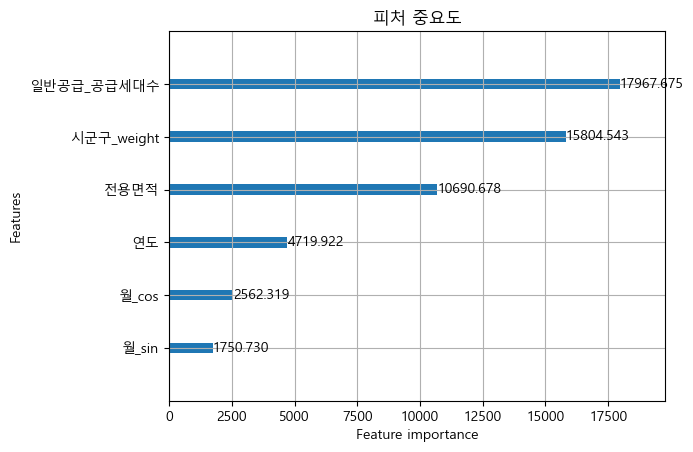

In [25]:
FEATURES = BASE + SUP_ORG + WEIGHT

# 가중치 + 로그 스케일링 기준
X = df[FEATURES].astype(float)
y = np.log1p(df[TARGET])  

model_1 = lgb.LGBMRegressor(
    n_estimators=700,
    learning_rate=0.04,
    num_leaves=40
)
model_1.fit(X, y)

# Gain 기반 피처 중요도
gain = model_1.booster_.feature_importance(importance_type='gain')
feature_gain = pd.DataFrame({
    "feature": FEATURES,
    "gain": gain
}).sort_values("gain", ascending=False)

lgb.plot_importance(model_1, importance_type='gain', max_num_features=20)
plt.title("피처 중요도")
plt.show()

예측 과정에서 가장 많이 사용한 컬럼들

| 순위                 | 피처                                | 
| ------------------ | --------------------------------- | 
|  일반공급 공급세대수  | 공급량이 많을수록 지원자 분포 예측에 핵심 단서        |  
|  시군구_weight  | 지역별 청약 선호도(입지 프리미엄)가 수요 편차를 크게 결정 |    
|  전용면적        | 선호 평형대 여부가 지원 패턴에 영향      |    
|  연도          | 부동산 사이클·정책 환경 변화 영향 존재            |    
|  월_sin/cos | 계절성·특정 분기별 청약심리 반영되나 영향은 제한적      |    

## SHAP 분석

In [26]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


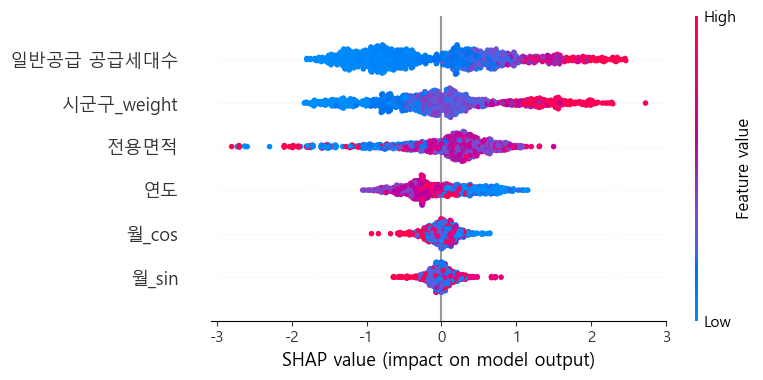

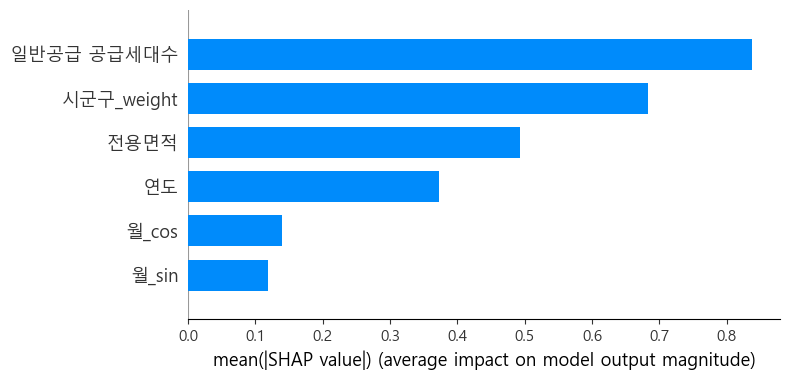

In [27]:
import shap

explainer = shap.TreeExplainer(model_1)
shap_values = explainer.shap_values(X)

# Dot summary (방향 + 분포)
shap.summary_plot(shap_values, X, show=True)

# Bar summary (절대 중요도)
shap.summary_plot(shap_values, X, plot_type="bar", show=True)

SHAP Summary Plot
| 피처             | SHAP 패턴 해석                                   |
| -------------- | -------------------------------------------- |
| 일반공급 공급세대수 | 세대수가 큰 단지가 더 많은 사람들이 몰리는 경향, 접수건수 많아짐      |
| 시군구_weight | weight 값이 높은 지역(강남·송파 등)은 지원자 증가 방향으로 강하게 기여 |
| 전용면적       | 특정 면적대에서 수요가 집중됨을 명확히 보여줌       |
| 연도         | 최근일수록 청약 관련 접수건수 소폭 상승, 이전 연도가 영향을 더 많이 줌            |
| 월_sin/cos  | 월별 계절적 요인 영향은 있으나 이 중에서는 영향이 제일 낮은 편        |

-----
SHAP BarPlot
| 순위            | SHAP 해석 결과              |
| ------------- | ----------------------- |
| 공급세대수      | 물량 자체가 수요 구조를 뒤흔듦       |
| 시군구_weight | 지역 프리미엄이 공급 못지않은 핵심 |
| 전용면적       | 인기평형 영향이 실제로 강함         |
| 연도         | 부동산 사이클 영향 존재(정책 경기변수)  |
| 월_sin/cos     | 분기성 영향 미미               |

## 분석 방향성 설정

가중치를 컬럼별로 좀 더 세분화, RankGauss는 미적용 예정
피처 40개 전체 다 써서 9월까지만, 2025 10 11 12 예측?

In [28]:
# 가중치 새로 적용하기 위해 이전 가중치는 이름 변경
df.rename(columns={'시군구_weight':'시군구_weight_raw'}, inplace=True)

# LGBM 모델링

## 최종 피처 정의

In [29]:
# 브랜드 자동분류 함수
def get_brand(danjiname):
    name = str(danjiname).lower()

    # 최상위 프리미엄
    if "acro" in name or "아크로" in name:
        return "아크로"
    if "the h" in name or "디에이치" in name:
        return "디에이치"
    if "le el" in name or "르엘" in name:
        return "르엘"
    if "포제스" in name:
        return "포제스"
    if "써밋" in name and ("푸르지오" not in name):  # 대우 '써밋'만 구분
        return "써밋"

    # 주요 1군
    if "래미안" in name:
        return "래미안"
    if "자이" in name or "xi" in name:
        return "자이"
    if "푸르지오" in name:
        return "푸르지오"
    if "힐스" in name:
        return "힐스테이트"
    if "ipark" in name or "아이파크" in name:
        return "아이파크"
    if "e편한" in name:
        return "e편한세상"

    # 기타 인기 브랜드
    if "더샵" in name:
        return "더샵"
    if "호반써밋" in name:
        return "호반써밋"
    if "트루엘" in name:
        return "더 트루엘"
    if "한신더휴" in name:
        return "한신더휴"
    if "우미린" in name:
        return "우미린"

    return "기타"

모델이 설명해야 하는 경쟁 정도를 위해 접수건수가 아닌 경쟁률 기반 가중치를 적용하기로 결정

In [30]:
# 브랜드 가중치 설정
brand_median = df.groupby("브랜드")["일반공급 경쟁률"].median()
overall_median = df["일반공급 경쟁률"].median()

brand_weight_raw = brand_median / overall_median
brand_weight = np.log1p(brand_weight_raw)  

In [31]:
df["브랜드_weight"] = df["브랜드"].map(brand_weight.to_dict())
df["브랜드_weight"] = df["브랜드_weight"].fillna(df["브랜드_weight"].median())

In [32]:
# 시/군/구 가중치 중앙값 기준 설정
gu_median = df.groupby("시/군/구")["일반공급 경쟁률"].median()

gu_weight_raw = gu_median / overall_median
gu_weight = np.log1p(gu_weight_raw)

In [33]:
df["시군구_weight"] = df["시/군/구"].map(gu_weight.to_dict())
df["시군구_weight"] = df["시군구_weight"].fillna(df["시군구_weight"].median())

In [34]:
remove_cols = [
    '일반공급 접수건수', 
    '일반공급 경쟁률', 
    '일반공급 미달여부', 
    '일반공급 미달세대수',
    'y', 
    '공급세대수_gauss',
    '모집공고일'
]

In [35]:
# feature 컬럼 자동 선정
feature_cols = [c for c in df.columns if c not in remove_cols]

# object → category 변환
for col in feature_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category')

## 모델 학습

In [36]:
# 2025년 9월 기준 데이터 분리 
cutoff = "2025-09-30"  

df['모집공고일'] = pd.to_datetime(df['모집공고일'])

df_train  = df[df['모집공고일'] <= cutoff].copy()
df_future = df[df['모집공고일'] > cutoff].copy()

In [37]:
# 타겟 변수 생성
df_train['target'] = np.log1p(df['일반공급 접수건수'])

In [38]:
from lightgbm import LGBMRegressor

X_train = df_train[feature_cols]
y_train = df_train['target']

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model_lgb = LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.85,
    colsample_bytree=0.7,
    random_state=42
)

model_lgb.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2181
[LightGBM] [Info] Number of data points in the train set: 1086, number of used features: 45
[LightGBM] [Info] Start training from score 6.026066


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,1200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# 테스트

In [39]:
df_train.columns.tolist()

['단지명',
 '주택형',
 '모집공고일',
 '주택관리번호',
 '생애최초 배정세대수',
 '신혼부부 배정세대수',
 '다자녀 배정세대수',
 '노부모 배정세대수',
 '해당지역 생애최초 접수건수',
 '해당지역 신혼부부 접수건수',
 '해당지역 다자녀 접수건수',
 '해당지역 노부모 접수건수',
 '기타지역 생애최초 접수건수',
 '기타지역 신혼부부 접수건수',
 '기타지역 다자녀 접수건수',
 '기타지역 노부모 접수건수',
 '연도',
 '월',
 '특별공급 총접수건수',
 '일반공급 접수건수',
 '일반공급 공급세대수',
 '일반공급 미달여부',
 '일반공급 미달세대수',
 '일반공급 경쟁률',
 '시/도',
 '시/군/구',
 '전용면적',
 'ESI',
 '기준금리',
 '전세지수',
 '매매지수',
 '생애최초비율',
 '신혼비율',
 '다자녀비율',
 '노부모비율',
 '강남권',
 '도심권',
 '한강권',
 'y',
 '정책버전',
 '경과개월',
 '월_sin',
 '월_cos',
 '특공_배정총합',
 '특공_접수총합',
 '주택형_알파벳',
 '브랜드',
 '특공존재여부',
 '특공무지원',
 '특공수요비율',
 '공급세대수_gauss',
 '시군구_weight_raw',
 '브랜드_weight',
 '시군구_weight',
 'target']

In [40]:
def predict_competition(model, df_ref, 연도, 월, 시군구, 단지명, 주택형, 특공접수총합, 일공공급세대수):

    row = {}

    # 기본 입력(미래에 알 수 있는 입력값)
    row['연도'] = 연도
    row['월'] = 월
    row['월_sin'] = np.sin(2*np.pi*월 / 12)
    row['월_cos'] = np.cos(2*np.pi*월 / 12)

    row['단지명'] = 단지명
    row['시/군/구'] = 시군구
    row['주택형'] = 주택형
    row['브랜드'] = get_brand(단지명)  # 브랜드 라벨링(위에서 정의된 함수 활용)

    row['브랜드_weight'] = brand_weight[row['브랜드']]  # 지역 및 브랜드 가중치
    row['시군구_weight'] = gu_weight[row['시/군/구']]

    row['특공_접수총합'] = 특공접수총합
    row['일반공급 공급세대수'] = 일공공급세대수

    # 나머지 feature 채워넣기
    for col in feature_cols:
        if col not in row:
            row[col] = (
                df_ref[col].median() if df_ref[col].dtype != 'category'  # 입력 안 한 특공 관련 변수 등은 훈련 데이터의 중앙값으로 채움
                else df_ref[col].mode()[0]
            )

    X = pd.DataFrame([row])

    # 카테고리 적용
    for col in feature_cols:
        if df_ref[col].dtype.name == 'category':  
            X[col] = X[col].astype('category').cat.set_categories(df_ref[col].cat.categories)  # test row가 train과 데이터 구조 동일하게 맞춤

    # 예측
    pred_log = model.predict(X[feature_cols])[0]
    pred = np.expm1(pred_log)  # 접수건수 예측
    ratio = pred / 일공공급세대수  # 자연스럽게 일공 경쟁률도 예측

    return pred, ratio

In [41]:
pred, ratio = predict_competition(
    model=model_lgb,
    df_ref=df_train,
    연도=2025,
    월=10,
    시군구='동작구',
    단지명='힐스테이트 이수역센트럴',
    주택형='084.8280B',
    특공접수총합=37,
    일공공급세대수=3
)

print(f"예상 일반공급 접수건수: {pred:.0f} 건")
print(f"예상 경쟁률: {ratio:.2f} 대 1")

예상 일반공급 접수건수: 256 건
예상 경쟁률: 85.44 대 1


In [42]:
pred, ratio = predict_competition(
    model=model_lgb,
    df_ref=df_train,
    연도=2025,
    월=11,
    시군구='서초구',
    단지명='반포 래미안 트리니원',
    주택형='084.9600B',
    특공접수총합=1600,
    일공공급세대수=14
)

print(f"예상 일반공급 접수건수: {pred:.0f} 건")
print(f"예상 경쟁률: {ratio:.2f} 대 1")

예상 일반공급 접수건수: 2195 건
예상 경쟁률: 156.77 대 1


In [43]:
pred, ratio = predict_competition(
    model=model_lgb,
    df_ref=df_train,
    연도=2025,
    월=12,
    시군구='구로구',
    단지명='리드 몬티온',
    주택형='084.7662B',
    특공접수총합=370,
    일공공급세대수=15
)

print(f"예상 일반공급 접수건수: {pred:.0f} 건")
print(f"예상 경쟁률: {ratio:.2f} 대 1")

예상 일반공급 접수건수: 98 건
예상 경쟁률: 6.56 대 1


기존보다 예상 경쟁률의 variation은 넓어졌는데, 다른 모델들에서도 적용해봤을 때 어떤 결과가 나올지 비교 분석 필요

피처 외 어떤 요소를 추가해야할지 고민(다른 부분에도 더 가중치를 줘야하나?  아님 애초에 특공 관련 이 영향을 거의 주지 않는 거는 아닌지? 등) 필요

## 테스트 결과 시각화

In [44]:
# 서울 아파트 테스트 데이터프레임 import
test_df = pd.read_csv(r'C:\Users\junsu\Documents\codeit_study\처음청약\apt_comparison_merge.csv', encoding='utf-8', na_values=[])
test_df.head(3)

,단지명,주택형,일반공급 접수건수,일반공급 경쟁률,예측_접수건수,예측_경쟁률
0,반포 래미안 트리니원,059.9400A,25251,245.16,7338,71.24
1,반포 래미안 트리니원,059.9800B,11518,198.59,6291,108.47
2,반포 래미안 트리니원,059.8500C,1980,152.31,2645,203.44


In [45]:
# 공백이나 보이지 않는 문자가 있을 수 있으니 스트립(strip) 후 필터링
test_df['주택형'] = test_df['주택형'].astype(str).str.strip()

# 확실하게 두 개만 뽑기
target_types = ['084.9600B', '074.8268']
filtered_df = test_df[test_df['주택형'].isin(target_types)].copy()

# 출력
filtered_df

,단지명,주택형,일반공급 접수건수,일반공급 경쟁률,예측_접수건수,예측_경쟁률
5,반포 래미안 트리니원,084.9600B,7440,531.43,5014,358.13
14,힐스테이트 이수역센트럴,074.8268,686,301.50,603,301.66


In [46]:
"""# 기존 데이터 설정 부분은 동일 
plot_df = filtered_df.copy()
plot_df['label'] = plot_df['단지명'] + "\n(" + plot_df['주택형'] + ")"

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white') 
ax.set_facecolor('white')

bar_width = 0.35
index = np.arange(len(plot_df))

bar1 = ax.bar(index, plot_df['일반공급 경쟁률'], bar_width, label='실제 경쟁률', color='#1d3557')
bar2 = ax.bar(index + bar_width, plot_df['예측_경쟁률'], bar_width, label='예측 경쟁률', color='#457b9d')

def add_labels(bars, color='black'): # 컬러 매개변수 추가
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, 
                    fontweight='bold', color=color) 

# 실제는 검정(기본), 예측은 빨강(red)으로 호출
add_labels(bar1, color='black')
add_labels(bar2, color='red') # 예측 수치만 빨간색

ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(plot_df['label'], fontsize=12)

# 범례 테두리 강화 
legend = ax.legend(
    loc='upper right', 
    frameon=True,          # 테두리 박스 활성화
    edgecolor='black',    # 테두리 선 색상을 완전 검정으로
    facecolor='white',     # 배경은 흰색
    framealpha=1,          # 배경 투명도 0 (완전 불투명)
    fontsize=11
)
# 범례 테두리 선 굵기를 1.5~2.0으로 설정 (배경 제거 시 선이 살아남음)
legend.get_frame().set_linewidth(1.5) 

# 불필요한 테두리(상단, 우측) 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()"""

'# 기존 데이터 설정 부분은 동일 \nplot_df = filtered_df.copy()\nplot_df[\'label\'] = plot_df[\'단지명\'] + "\n(" + plot_df[\'주택형\'] + ")"\n\nfig, ax = plt.subplots(figsize=(10, 6))\nfig.patch.set_facecolor(\'white\') \nax.set_facecolor(\'white\')\n\nbar_width = 0.35\nindex = np.arange(len(plot_df))\n\nbar1 = ax.bar(index, plot_df[\'일반공급 경쟁률\'], bar_width, label=\'실제 경쟁률\', color=\'#1d3557\')\nbar2 = ax.bar(index + bar_width, plot_df[\'예측_경쟁률\'], bar_width, label=\'예측 경쟁률\', color=\'#457b9d\')\n\ndef add_labels(bars, color=\'black\'): # 컬러 매개변수 추가\n    for bar in bars:\n        height = bar.get_height()\n        ax.annotate(f\'{height:.1f}\',\n                    xy=(bar.get_x() + bar.get_width() / 2, height),\n                    xytext=(0, 3), textcoords="offset points",\n                    ha=\'center\', va=\'bottom\', fontsize=11, \n                    fontweight=\'bold\', color=color) \n\n# 실제는 검정(기본), 예측은 빨강(red)으로 호출\nadd_labels(bar1, color=\'black\')\nadd_labels(bar2, color=\'red\') # 예측 수치만 

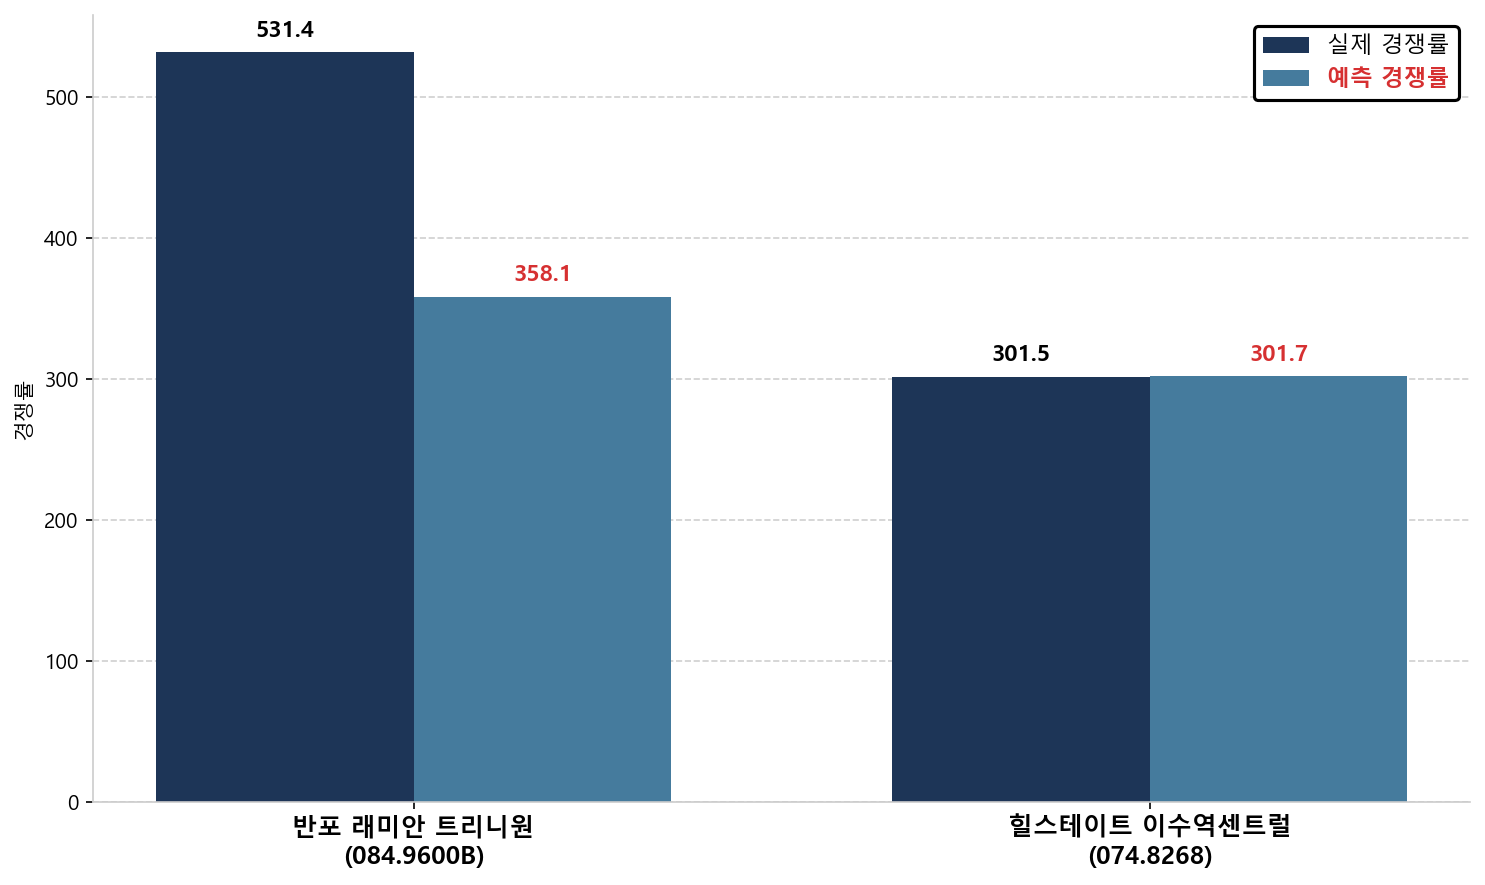

In [47]:
plot_df = filtered_df.copy()
plot_df['label'] = plot_df['단지명'] + "\n(" + plot_df['주택형'] + ")"

fig, ax = plt.subplots(figsize=(10, 6), dpi=150) # 해상도를 높여서 생성
fig.patch.set_facecolor('white') 
ax.set_facecolor('white')

bar_width = 0.35
index = np.arange(len(plot_df))

bar1 = ax.bar(index, plot_df['일반공급 경쟁률'], bar_width, label='실제 경쟁률', color='#1d3557')
bar2 = ax.bar(index + bar_width, plot_df['예측_경쟁률'], bar_width, label='예측 경쟁률', color='#457b9d')

# 수치 레이블 추가 함수 (예측 수치만 빨간색 강조)
def add_labels(bars, color='black'):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, 
                    fontweight='bold', color=color) 

add_labels(bar1, color='black')
add_labels(bar2, color='#d63031') # 예측 수치만 진한 빨간색

# 축 설정
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(plot_df['label'], fontsize=12, fontweight='bold')
ax.set_ylabel('경쟁률', fontsize=10)

# Y축 그리드 추가 (분석 리포트 가독성 향상)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True) # 그리드를 막대 뒤로

# 범례 설정 및 예측 텍스트 강조
legend = ax.legend(loc='upper right', frameon=True, edgecolor='black', facecolor='white', framealpha=1, fontsize=11)
legend.get_frame().set_linewidth(1.5) 

# 범례의 '예측 경쟁률' 텍스트만 빨간색으로 변경
for text in legend.get_texts():
    if '예측' in text.get_text():
        text.set_color('#d63031')
        text.set_fontweight('bold')

# 테두리 정리
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.show()

# 추가로 고려할 만한 요소/ 피처

| 추가 요소 / 피처                                                                    | 왜 유용한지                                    |
| ----------------------------------------------------------------------------- | ----------------------------------------- |
| **청약가점 경쟁지표 (예: 최근 동일 구역 내 1~2년간 청약 평균 청약가점, 미달률, 당첨가점 평균 등)**                | 과거 청약의 “얼마나 경쟁이 치열했는지”를 반영 → 수요 강도의 직접 지표 |
| 실거래 / 시세 변화 속도 (예: 모집공고일 전 6~12개월간 해당 구/단지 인근 아파트 가격 상승률)                 | 사람들이 “분양받으면 이익 볼까?” 기대 반영 → 수요에 큰 영향      |
| 금리 변화 + 대출 규제 변수 + 대출 이자 부담 지표                                            | 청약은 자금 조달 가능성과 직결 → 금리/대출 규제시 수요 급변       |
| 공급 스펙 관련 변수 (예: 면적 구성 비율, 동 수, 층수, 조경/커뮤니티 수준, 브랜드 시공사 점수 등)            | 단순 공급세대수보다 “얼마나 매력적인 공급인가”가 중요            |
| 과거 해당 브랜드 / 시군구의 실제 당첨/청약 기록 통계 (예: 최근 3년 간 동일 브랜드·지역 경쟁률 평균, 당첨률, 미달률 등) | “프리미엄 브랜드 + 지역”이라도 최근 시장 피로도 반영 가능성 존재    |

# 추후 고려할 모델 종류

1. **CatBoost**: 기존 LGBM에서 문제였던 카테고리 처리, 가중치 왜곡, 로그 스케일링 변환 관련 문제 해결에 용이(**3.10.0 버전에서 가능**, 가상환경 생성해서 따로 작업 필요)
2. **XGBoost + TargetEncoder (시군구/브랜드)**: 학습 데이터가 늘어나거나 다른 추가 피처 들어갈 때 평균적으로 안정성 높음
3. **CatBoost + LGBM / XGB Stacking (Ensemble)**: 단일 모델이 가질 수 밖에 없는 Bias 상쇄 가능성
4. **GLM(Generalized Linear Model, Poisson / Tweedie Regression 적용)**: 소량 데이터(1k↓)의 극단값 편차를 완화하고 비즈니스 해석력을 극대화한 Poisson 기반 통계 모델링

# CatBoost 모델링

In [48]:
pip install catboost

In [49]:
from catboost import CatBoostRegressor
import numpy as np
import pandas as pd

# 가중치 생성 
brand_median = df.groupby("브랜드")["일반공급 경쟁률"].median()
overall_median = df["일반공급 경쟁률"].median()

brand_weight_raw = brand_median / overall_median
brand_weight = np.log1p(brand_weight_raw)
df["브랜드_weight"] = df["브랜드"].map(brand_weight.to_dict())
df["브랜드_weight"] = df["브랜드_weight"].astype(float)
df["브랜드_weight"] = df["브랜드_weight"].fillna(df["브랜드_weight"].median())

gu_median = df.groupby("시/군/구")["일반공급 경쟁률"].median()
gu_weight_raw = gu_median / overall_median
gu_weight = np.log1p(gu_weight_raw)
df["시군구_weight"] = df["시/군/구"].map(gu_weight.to_dict())
df["시군구_weight"] = df["시군구_weight"].astype(float)
df["시군구_weight"] = df["시군구_weight"].fillna(df["시군구_weight"].median())

# 타깃 구성 (접수건수 log1p)
df["target"] = np.log1p(df["일반공급 접수건수"])

# feature_cols 동일
remove_cols = [
    '일반공급 접수건수', '일반공급 경쟁률', '일반공급 미달여부', '일반공급 미달세대수',
    '공급세대수_gauss', 'y', '모집공고일', 'target'
]
feature_cols = [c for c in df.columns if c not in remove_cols]

# 카테고리 타입 원본 유지 
for col in feature_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category')

# 시계열 분리
df['모집공고일'] = pd.to_datetime(df['모집공고일'])
cutoff = "2025-09-30"

df_train  = df[df['모집공고일'] <= cutoff].copy()
df_future = df[df['모집공고일'] > cutoff].copy()

X_train = df_train[feature_cols]
y_train = df_train['target']

# CatBoost가 처리해야 하는 category 컬럼 인덱스 구하기
cat_cols = [X_train.columns.get_loc(c) for c in X_train.columns if str(X_train[c].dtype) == "category"]

# CatBoost 모델 정의 
model_cat = CatBoostRegressor(
    iterations=1200,          # n_estimators 역할
    learning_rate=0.03,
    depth=7,                  # max_depth
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

# 학습 (LGBM과 동일 target)
model_cat.fit(
    X_train,
    y_train,
    cat_features=cat_cols
)

# 미래 데이터 예측
X_future = df_future[feature_cols]
pred_log = model_cat.predict(X_future)
pred = np.expm1(pred_log)  # log → 원복 접수건수

df_future["예측_접수건수"] = pred
df_future["예측_경쟁률"] = df_future["예측_접수건수"] / df_future["일반공급 공급세대수"]

print(df_future[["단지명", "주택형", "예측_접수건수", "예측_경쟁률"]].head(10))

            단지명        주택형      예측_접수건수      예측_경쟁률
0   반포 래미안 트리니원  059.9400A  7338.163494   71.244306
1   반포 래미안 트리니원  059.9800B  6291.399736  108.472409
2   반포 래미안 트리니원  059.8500C  2644.685534  203.437349
3   반포 래미안 트리니원  059.9100D  4954.154627  145.710430
4   반포 래미안 트리니원  084.9100A  1895.485261  315.914210
5   반포 래미안 트리니원  084.9600B  5013.853468  358.132391
6   반포 래미안 트리니원  084.9600C  1285.571881  642.785941
7  힐스테이트 이수역센트럴  044.7578A  1142.526881   95.210573
8  힐스테이트 이수역센트럴  044.7578B   270.583362   90.194454
9  힐스테이트 이수역센트럴  049.5998A  2070.640019   86.276667


In [50]:
df[["단지명", "주택형", "일반공급 접수건수", "일반공급 경쟁률"]].head(19)

,단지명,주택형,일반공급 접수건수,일반공급 경쟁률
0,반포 래미안 트리니원,059.9400A,25251,245.16
1,반포 래미안 트리니원,059.9800B,11518,198.59
2,반포 래미안 트리니원,059.8500C,1980,152.31
3,반포 래미안 트리니원,059.9100D,4871,143.26
4,반포 래미안 트리니원,084.9100A,2744,457.33
5,반포 래미안 트리니원,084.9600B,7440,531.43
6,반포 래미안 트리니원,084.9600C,827,413.50
7,힐스테이트 이수역센트럴,044.7578A,2610,181.17
8,힐스테이트 이수역센트럴,044.7578B,504,132.67
9,힐스테이트 이수역센트럴,049.5998A,7285,265.33


In [51]:
# 정수형(int)으로 변환
df_future['예측_접수건수'] = df_future['예측_접수건수'].round(0).astype(int)

# 예측_경쟁률: 소수점 둘째자리까지 반올림
df_future['예측_경쟁률'] = df_future['예측_경쟁률'].round(2)

# 확인용 출력
df_future[["단지명", "주택형", "예측_접수건수", "예측_경쟁률"]]

,단지명,주택형,예측_접수건수,예측_경쟁률
0,반포 래미안 트리니원,059.9400A,7338,71.24
1,반포 래미안 트리니원,059.9800B,6291,108.47
2,반포 래미안 트리니원,059.8500C,2645,203.44
3,반포 래미안 트리니원,059.9100D,4954,145.71
4,반포 래미안 트리니원,084.9100A,1895,315.91
5,반포 래미안 트리니원,084.9600B,5014,358.13
6,반포 래미안 트리니원,084.9600C,1286,642.79
7,힐스테이트 이수역센트럴,044.7578A,1143,95.21
8,힐스테이트 이수역센트럴,044.7578B,271,90.19
9,힐스테이트 이수역센트럴,049.5998A,2071,86.28


# XGBoost 모델링